In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
RANDOM_STATE = 42


In [2]:
data_path = 'cleaned_dataset.csv'
df = pd.read_csv(data_path)

target_col = 'Stock_Return'
df['Return_Realized_Year'] = df['Year'] + 1

drop_cols = ['Ticker', 'Sector', 'Stock_Return', 'Class', 'Year', 'Return_Direction', 'Return_Realized_Year']
feature_cols = [col for col in df.columns if col not in drop_cols]

train_df = df[df['Year'] < 2018].copy()
test_df = df[df['Year'] == 2018].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

print(f'Total observations: {len(df):,}')
print(f'Number of features used: {len(feature_cols)}')
print(f'Training rows (feature years 2014-2017): {len(train_df):,}')
print(f'Test rows (feature year 2018): {len(test_df):,}')
print(f'Missing values in selected features: {df[feature_cols].isna().sum().sum():,}')


Total observations: 22,031
Number of features used: 201
Training rows (feature years 2014-2017): 17,641
Test rows (feature year 2018): 4,390
Missing values in selected features: 0


In [3]:
feature_year_summary = df.groupby('Year')[target_col].agg(['count', 'mean', 'median', 'std']).round(3)
realized_year_summary = df.groupby('Return_Realized_Year')[target_col].agg(['count', 'mean', 'median', 'std']).round(3)
split_summary = pd.DataFrame({
    'Train (feature years 2014-2017, returns 2015-2018)': train_df[target_col].agg(['count', 'mean', 'median', 'std']),
    'Test (feature year 2018, returns 2019)': test_df[target_col].agg(['count', 'mean', 'median', 'std']),
}).T.round(3)

print('Summary by feature year:')
display(feature_year_summary)
print('Summary by realised return year:')
display(realized_year_summary)
print('Train-test target shift:')
display(split_summary)


Summary by feature year:


,count,mean,median,std
Year,,,,
2014,3787,-5.001,-5.514,43.156
2015,4114,20.475,17.260,54.212
2016,4783,17.557,10.811,55.226
2017,4957,-13.463,-13.364,40.849
2018,4390,19.665,17.589,57.304


Summary by realised return year:


,count,mean,median,std
Return_Realized_Year,,,,
2015,3787,-5.001,-5.514,43.156
2016,4114,20.475,17.260,54.212
2017,4783,17.557,10.811,55.226
2018,4957,-13.463,-13.364,40.849
2019,4390,19.665,17.589,57.304


Train-test target shift:


,count,mean,median,std
"Train (feature years 2014-2017, returns 2015-2018)",17641.0,4.679,0.981,50.954
"Test (feature year 2018, returns 2019)",4390.0,19.665,17.589,57.304


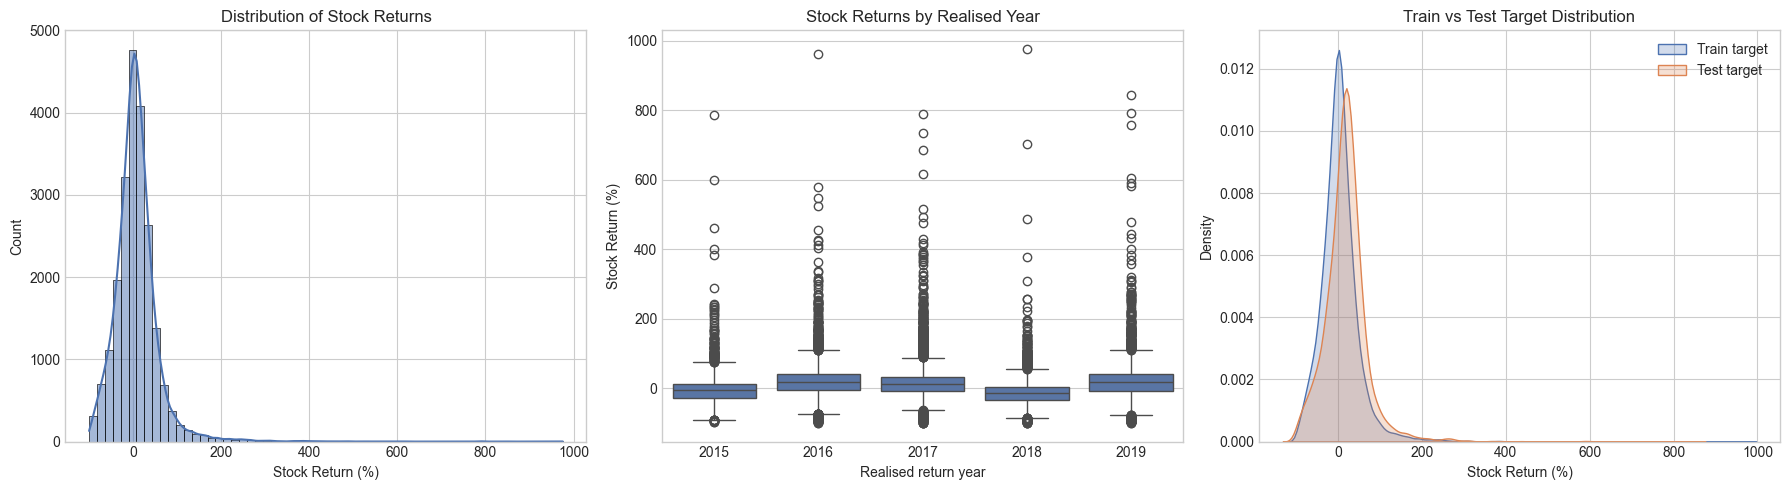

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df[target_col], bins=60, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Stock Returns')
axes[0].set_xlabel('Stock Return (%)')

sns.boxplot(data=df, x='Return_Realized_Year', y=target_col, ax=axes[1])
axes[1].set_title('Stock Returns by Realised Year')
axes[1].set_xlabel('Realised return year')
axes[1].set_ylabel('Stock Return (%)')

sns.kdeplot(train_df[target_col], fill=True, label='Train target', ax=axes[2])
sns.kdeplot(test_df[target_col], fill=True, label='Test target', ax=axes[2])
axes[2].set_title('Train vs Test Target Distribution')
axes[2].set_xlabel('Stock Return (%)')
axes[2].legend()

plt.tight_layout()
plt.show()


In [5]:
param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
}

years = train_df['Year'].values
expanding_cv = [
    (np.where(years <= 2014)[0], np.where(years == 2015)[0]),
    (np.where(years <= 2015)[0], np.where(years == 2016)[0]),
    (np.where(years <= 2016)[0], np.where(years == 2017)[0]),
]

grid_search = GridSearchCV(
    RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    param_grid,
    cv=expanding_cv,
    scoring='neg_root_mean_squared_error',
    refit=False,
    verbose=1,
)
grid_search.fit(X_train, y_train)

cv_results = pd.DataFrame(grid_search.cv_results_).sort_values('rank_test_score')
display_cols = [
    'param_n_estimators', 'param_max_depth', 'param_min_samples_split',
    'mean_test_score', 'std_test_score', 'rank_test_score',
]
cv_top = cv_results[display_cols].head(10).copy()
cv_top['cv_rmse'] = -cv_top['mean_test_score']
cv_top = cv_top.drop(columns=['mean_test_score']).rename(columns={'std_test_score': 'cv_rmse_std'})
print('Top 10 configurations by CV RMSE:')
display(cv_top)

best_params = grid_search.best_params_.copy()
print(f'\nBest configuration: {best_params}')
print(f'Best CV RMSE: {-grid_search.best_score_:.3f}')


Fitting 3 folds for each of 18 candidates, totalling 54 fits
Top 10 configurations by CV RMSE:


,param_n_estimators,param_max_depth,param_min_samples_split,cv_rmse_std,rank_test_score,cv_rmse
5,300,5,10,5.268121,1,55.272425
3,300,5,5,5.299047,2,55.300209
1,300,5,2,5.302651,3,55.302674
4,100,5,10,5.159753,4,55.334591
2,100,5,5,5.156982,5,55.376785
0,100,5,2,5.171439,6,55.380530
11,300,10,10,5.107738,7,56.090506
9,300,10,5,5.143025,8,56.139857
7,300,10,2,5.177305,9,56.161620
10,100,10,10,4.939833,10,56.261010



Best configuration: {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 300}
Best CV RMSE: 55.272


In [6]:
rf_reg = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **best_params,
)
rf_reg.fit(X_train, y_train)

rf_preds = rf_reg.predict(X_test)
baseline_preds = np.full_like(y_test, y_train.mean(), dtype=float)

results_table = pd.DataFrame([
    {
        'Model': 'Mean baseline',
        'RMSE': np.sqrt(mean_squared_error(y_test, baseline_preds)),
        'R2': r2_score(y_test, baseline_preds),
    },
    {
        'Model': 'Random Forest Regressor',
        'RMSE': np.sqrt(mean_squared_error(y_test, rf_preds)),
        'R2': r2_score(y_test, rf_preds),
    },
]).round(4)
display(results_table)

print(f'Training target mean: {y_train.mean():.3f}')
print(f'Test target mean: {y_test.mean():.3f}')
print(f'Average random forest prediction: {rf_preds.mean():.3f}')

prediction_frame = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': rf_preds,
    'Residual': y_test.values - rf_preds,
})
prediction_frame.head()


,Model,RMSE,R2
0,Mean baseline,59.2247,-0.0684
1,Random Forest Regressor,58.8727,-0.0557


Training target mean: 4.679
Test target mean: 19.665
Average random forest prediction: 7.685


,Actual,Predicted,Residual
0,32.794573,8.428100,24.366473
1,40.588068,2.677182,37.910886
2,30.295514,3.420092,26.875422
3,64.213737,1.890678,62.323059
4,44.757840,12.207933,32.549908


In [7]:
comparison_table = test_df[['Ticker', 'Year', 'Return_Realized_Year']].copy()
comparison_table = comparison_table.rename(columns={'Year': 'Feature_Year'})
comparison_table['Actual_Return'] = y_test.values
comparison_table['Predicted_Return'] = rf_preds
comparison_table['Residual'] = comparison_table['Actual_Return'] - comparison_table['Predicted_Return']
comparison_table['Absolute_Error'] = comparison_table['Residual'].abs()
comparison_table = comparison_table.sort_values('Ticker').reset_index(drop=True)
comparison_table[['Actual_Return', 'Predicted_Return', 'Residual', 'Absolute_Error']] = (
    comparison_table[['Actual_Return', 'Predicted_Return', 'Residual', 'Absolute_Error']].round(4)
)

print(f'Full stock-level comparison table rows: {len(comparison_table):,}')
display(comparison_table)


Full stock-level comparison table rows: 4,390


,Ticker,Feature_Year,Return_Realized_Year,Actual_Return,Predicted_Return,Residual,Absolute_Error
0,A,2018,2019,30.9761,8.4351,22.5410,22.5410
1,AA,2018,2019,-18.0259,8.6449,-26.6709,26.6709
2,AABA,2018,2019,25.2575,15.7779,9.4796,9.4796
3,AAL,2018,2019,-10.6021,8.4148,-19.0168,19.0168
4,AAMC,2018,2019,-58.8471,-4.4666,-54.3805,54.3805
...,...,...,...,...,...,...,...
4385,ZTR,2018,2019,42.5715,9.5760,32.9955,32.9955
4386,ZTS,2018,2019,57.6627,9.3574,48.3053,48.3053
4387,ZUMZ,2018,2019,76.0448,6.1373,69.9075,69.9075
4388,ZYME,2018,2019,209.4622,12.1979,197.2643,197.2643


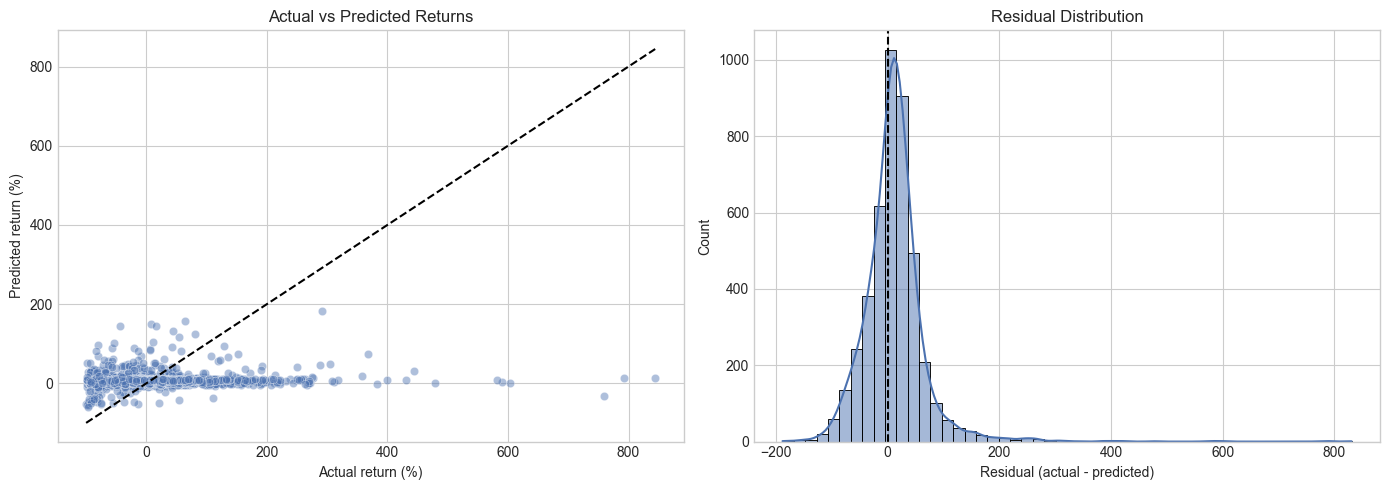

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=prediction_frame, x='Actual', y='Predicted', alpha=0.45, ax=axes[0])
min_val = min(prediction_frame['Actual'].min(), prediction_frame['Predicted'].min())
max_val = max(prediction_frame['Actual'].max(), prediction_frame['Predicted'].max())
axes[0].plot([min_val, max_val], [min_val, max_val], linestyle='--', color='black')
axes[0].set_title('Actual vs Predicted Returns')
axes[0].set_xlabel('Actual return (%)')
axes[0].set_ylabel('Predicted return (%)')

sns.histplot(prediction_frame['Residual'], bins=50, kde=True, ax=axes[1])
axes[1].axvline(0, linestyle='--', color='black')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual (actual - predicted)')

plt.tight_layout()
plt.show()


,importance
EPS Diluted,0.066448
priceToBookRatio,0.063296
freeCashFlowOperatingCashFlowRatio,0.061524
Earnings Yield,0.061057
Weighted Average Shs Out,0.035049
Weighted Average Shs Out (Dil),0.031432
Operating Cash Flow per Share,0.025123
5Y Revenue Growth (per Share),0.025007
Capex to Depreciation,0.022560
Investment purchases and sales,0.021709


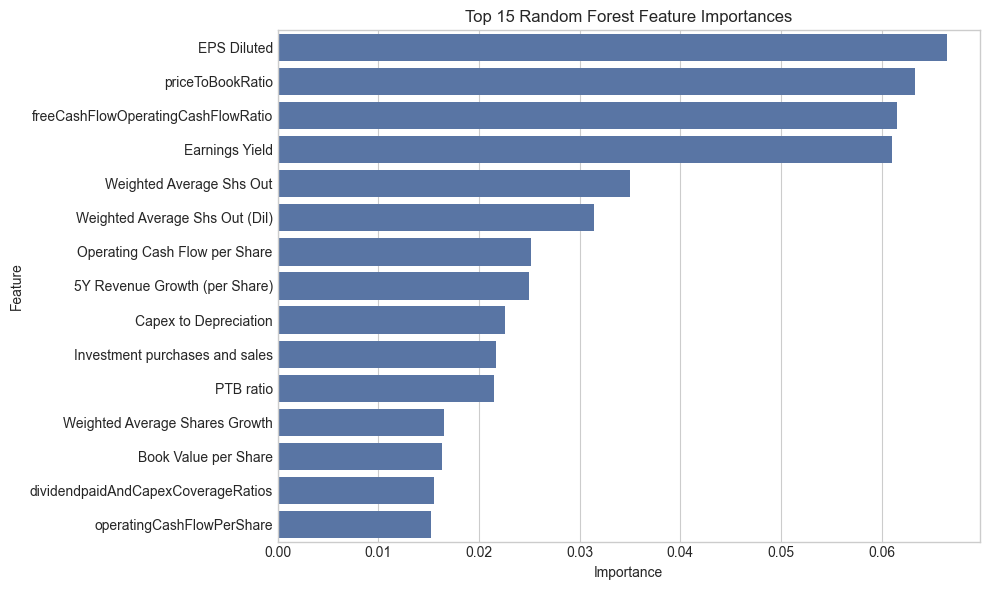

In [9]:
feature_importance = pd.Series(rf_reg.feature_importances_, index=feature_cols).sort_values(ascending=False)
top_features = feature_importance.head(15)
display(top_features.to_frame('importance'))

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index, orient='h')
plt.title('Top 15 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()
